# DTLZ2 Results

In [1]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 640
NGEN = 500
NOBJ = 4 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz2_segura = partial(benchmarks.dtlz2, obj=NOBJ)
toolbox = build_toolbox(func_dtlz2_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


(6.123233996592594e-17, 1.0000000001397673, 0.0, 0.0)
(3.7494796696754184e-33, 0.0, 6.123364993540917e-17, 1.0000213935649434)
(1.000000000140454, 0.0, 0.0, 0.0)
(1.000000000140454, 0.0, 0.0, 0.0)
(2.832769729732291e-16, 0.0, 0.0, 1.0000000991638418)
(3.9758898008224727e-22, 6.963520024332699e-17, 0.0, 1.137229122599998)
(2.2958450219741788e-49, 3.74939945717024e-33, 6.123233996578797e-17, 1.0000000001375142)
(6.336672162662831e-17, 9.337639485850401e-18, 1.0460325075634749, 0.0)
(0.04003754688073738, 0.07249726577975513, 0.9309662342584933, 0.35576287217796926)
(0.8381444896231899, 0.09084844141544139, 0.25199855639999075, 0.47833621536587295)
(0.0656290945732581, 0.5413337217313493, 0.5671807252972446, 0.6367595609474743)
(0.097560319519715, 0.8231776890159678, 0.19954421265283814, 0.5300902741070186)
(0.18406603979732225, 0.6300297208137394, 0.39747079369662036, 0.6659501104306995)
(0.5928523460944107, 0.7699935269549631, 0.07964341631826445, 0.22229798710742424)
(0.3151201405036720

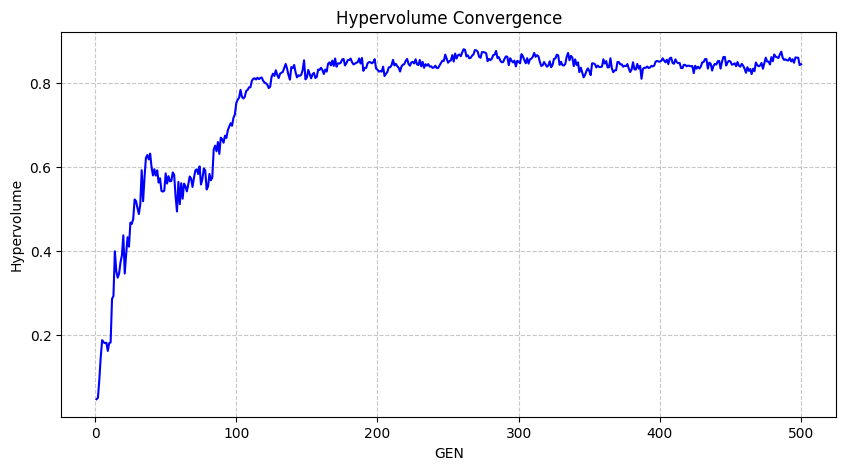

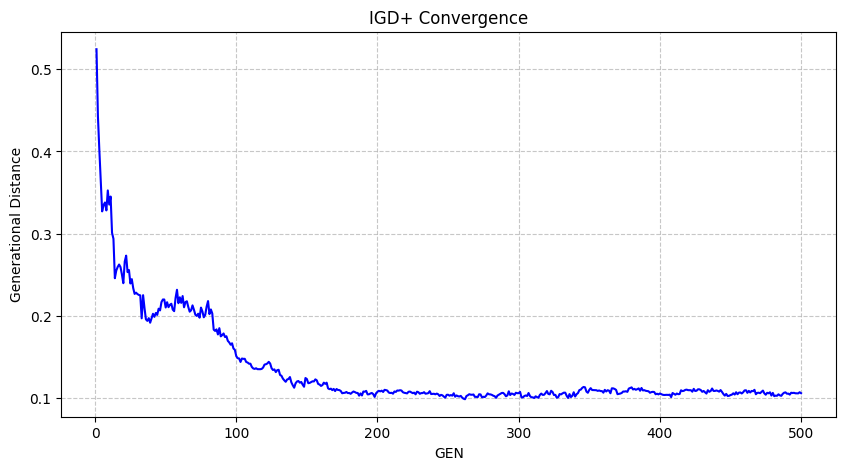

In [ ]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
    print(ind.fitness.values)
print(tabelas[0])
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
\
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()